## 1. Importar Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import s3fs
import boto3
from loguru import logger
import warnings

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Configuración de AWS y Conexión a S3

Este código usa las credenciales configuradas con `aws configure`. Asegúrate de haber ejecutado:
```bash
aws configure
```

Y haber ingresado:
- AWS Access Key ID
- AWS Secret Access Key
- Default region name (ej: us-east-1)
- Default output format (json)

In [3]:
# Configuración de S3
AWS_REGION = 'us-east-1'
BUCKET = 'dcelip-dev-brz-fraud-s3'
FILE_PATH = 'modelo_fraude/input/raw/df_fraudes.parquet'

# Ruta completa en S3
S3_PATH = f's3://{BUCKET}/{FILE_PATH}'

print(f"📍 Bucket: {BUCKET}")
print(f"📂 Ruta del archivo: {FILE_PATH}")
print(f"🔗 Ruta completa S3: {S3_PATH}")

📍 Bucket: dcelip-dev-brz-fraud-s3
📂 Ruta del archivo: modelo_fraude/input/raw/df_fraudes.parquet
🔗 Ruta completa S3: s3://dcelip-dev-brz-fraud-s3/modelo_fraude/input/raw/df_fraudes.parquet


## 3. Cargar Datos desde S3

In [4]:
# Inicializar el sistema de archivos S3 con credenciales AWS
# s3fs usará automáticamente las credenciales configuradas con aws configure
# anon=False asegura que use las credenciales configuradas
fs = s3fs.S3FileSystem(
    anon=False,
    client_kwargs={'region_name': AWS_REGION}
)

print("🔑 Usando credenciales configuradas con AWS CLI")
print("✅ Conexión S3 inicializada")

🔑 Usando credenciales configuradas con AWS CLI
✅ Conexión S3 inicializada


In [5]:
# Verificar que el archivo existe
s3_key = S3_PATH.replace('s3://', '')
print(f"🔍 Verificando: {s3_key}\n")

try:
    file_exists = fs.exists(s3_key)
    
    if file_exists:
        print(f"✅ Archivo encontrado en S3: {FILE_PATH}")
        
        # Obtener información del archivo
        file_info = fs.info(s3_key)
        file_size_mb = file_info['Size'] / (1024 * 1024)
        print(f"📊 Tamaño del archivo: {file_size_mb:.2f} MB")
    else:
        print(f"❌ Archivo NO encontrado en S3: {S3_PATH}")
        print("\nIntentando listar el bucket para verificar...")
        
        # Intentar listar los primeros archivos del bucket
        try:
            files = fs.ls(BUCKET, detail=False)[:5]
            print(f"\nPrimeros archivos en el bucket:")
            for f in files:
                print(f"  - {f}")
        except Exception as list_error:
            print(f"❌ Error al listar bucket: {list_error}")
        
        print("\nVerifica:")
        print("1. Las credenciales AWS están configuradas correctamente")
        print("2. La ruta del archivo es correcta")
        print("3. Tienes permisos de lectura en el bucket")

except Exception as e:
    print(f"❌ Error al verificar el archivo: {e}")
    print(f"\nIntenta ejecutar en terminal:")
    print(f"aws s3 ls s3://{BUCKET}/{FILE_PATH}")
    raise

🔍 Verificando: dcelip-dev-brz-fraud-s3/modelo_fraude/input/raw/df_fraudes.parquet

✅ Archivo encontrado en S3: modelo_fraude/input/raw/df_fraudes.parquet
📊 Tamaño del archivo: 1.35 MB


In [6]:
# Cargar el archivo parquet desde S3
print("📥 Cargando datos desde S3...")

try:
    df = pd.read_parquet(
        S3_PATH,
        storage_options={'use_ssl': True}
    )
    
    print(f"\n✅ Datos cargados exitosamente!")
    print(f"📊 Forma del dataset: {df.shape}")
    print(f"   - Filas: {df.shape[0]:,}")
    print(f"   - Columnas: {df.shape[1]}")
    
except Exception as e:
    print(f"\n❌ Error al cargar el archivo: {e}")
    raise

📥 Cargando datos desde S3...

✅ Datos cargados exitosamente!
📊 Forma del dataset: (63019, 27)
   - Filas: 63,019
   - Columnas: 27


## 4. Exploración Inicial de Datos

In [7]:
# Primeras filas
print("📋 Primeras 5 filas del dataset:\n")
df.head()

📋 Primeras 5 filas del dataset:



,FRecep,Socio,ID_TARJETA,Aut,Ffraud,NOperacion,Valor,Pais,TipoFraude,Decision,Entidad,Marca,FuentePF,Fuente,Marca2,Autorizacion,ID_Tarjeta2,RED,SUBRED,Cod_Lectura,Cod_Pais,Giro,Eci_UcafC,Token,Fvigencia,NiveldeRiesgo,source
0,2025-08-22,HERRERA GILBERT MARIA DEL PILAR,42201455,None,0007-12-25,NaN,"13,06",None,None,P&G,DC,DN,MENORES,INTERNACIONAL,DCDN,NaN,None,Propias,Manual,01-Manual,840.0,8999.0,,,None,,teradata
1,2025-08-22,HERRERA GILBERT MARIA DEL PILAR,42201455,None,0007-12-25,NaN,"12,74",None,None,P&G,DC,DN,MENORES,INTERNACIONAL,DCDN,NaN,None,Propias,Manual,01-Manual,840.0,8999.0,,,None,,teradata
2,2025-08-22,HERRERA GILBERT MARIA DEL PILAR,42201455,None,None,NaN,"9,42",None,None,P&G,DC,DN,MENORES,INTERNACIONAL,DCDN,NaN,None,Propias,Manual,01-Manual,840.0,8999.0,,,None,,teradata
3,2025-08-22,HERRERA GILBERT MARIA DEL PILAR,42201455,None,0007-12-25,NaN,"9,40",None,None,P&G,DC,DN,MENORES,INTERNACIONAL,DCDN,NaN,None,Propias,Manual,01-Manual,840.0,8999.0,,,None,,teradata
4,2025-08-22,HERRERA GILBERT MARIA DEL PILAR,42201455,None,0007-12-25,NaN,"6,17",None,None,P&G,DC,DN,MENORES,INTERNACIONAL,DCDN,NaN,None,Propias,Manual,01-Manual,840.0,8999.0,,,None,,teradata


In [8]:
# Información general del dataset
print("ℹ️ Información del dataset:\n")
df.info()

ℹ️ Información del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63019 entries, 0 to 63018
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   FRecep         63019 non-null  object  
 1   Socio          43714 non-null  object  
 2   ID_TARJETA     63019 non-null  object  
 3   Aut            15050 non-null  object  
 4   Ffraud         25249 non-null  object  
 5   NOperacion     15050 non-null  float64 
 6   Valor          63014 non-null  object  
 7   Pais           14869 non-null  object  
 8   TipoFraude     15012 non-null  object  
 9   Decision       43717 non-null  object  
 10  Entidad        63019 non-null  object  
 11  Marca          63019 non-null  object  
 12  FuentePF       63019 non-null  object  
 13  Fuente         63019 non-null  object  
 14  Marca2         63019 non-null  object  
 15  Autorizacion   15047 non-null  float64 
 16  ID_Tarjeta2    15047 non-null  object  
 17  RE

In [9]:
# Estadísticas descriptivas
print("📊 Estadísticas descriptivas (numéricas):\n")
df.describe()

📊 Estadísticas descriptivas (numéricas):



,NOperacion,Autorizacion,Cod_Pais,Giro
count,1.505000e+04,15047.000000,43717.000000,43717.000000
mean,4.905580e+07,497486.715558,649.410184,7873.212572
std,2.868535e+07,290917.718845,304.513469,1659.300249
min,2.729300e+04,0.000000,0.000000,0.000000
25%,2.464522e+07,244553.000000,218.000000,5921.000000
50%,4.768711e+07,498833.000000,840.000000,8999.000000
75%,7.395577e+07,748297.000000,840.000000,8999.000000
max,9.999044e+07,999746.000000,894.000000,9752.000000


In [11]:
# Estadísticas descriptivas para variables categóricas
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    print("📊 Estadísticas descriptivas (categóricas):\n")
    df[categorical_cols].describe()

📊 Estadísticas descriptivas (categóricas):



## 5. Análisis de Valores Faltantes

In [12]:
# Análisis de valores nulos
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100

null_df = pd.DataFrame({
    'Columna': null_counts.index,
    'Valores Nulos': null_counts.values,
    'Porcentaje (%)': null_percentages.values
}).sort_values('Valores Nulos', ascending=False)

# Filtrar solo columnas con nulos
null_df = null_df[null_df['Valores Nulos'] > 0]

if len(null_df) > 0:
    print(f"⚠️ Se encontraron {len(null_df)} columnas con valores faltantes:\n")
    display(null_df)
else:
    print("✅ No se encontraron valores faltantes en el dataset")

⚠️ Se encontraron 17 columnas con valores faltantes:



,Columna,Valores Nulos,Porcentaje (%)
7,Pais,48150,76.405528
8,TipoFraude,48007,76.178613
24,Fvigencia,47983,76.140529
16,ID_Tarjeta2,47972,76.123074
15,Autorizacion,47972,76.123074
5,NOperacion,47969,76.118314
3,Aut,47969,76.118314
4,Ffraud,37770,59.934306
1,Socio,19305,30.633618
18,SUBRED,19302,30.628858


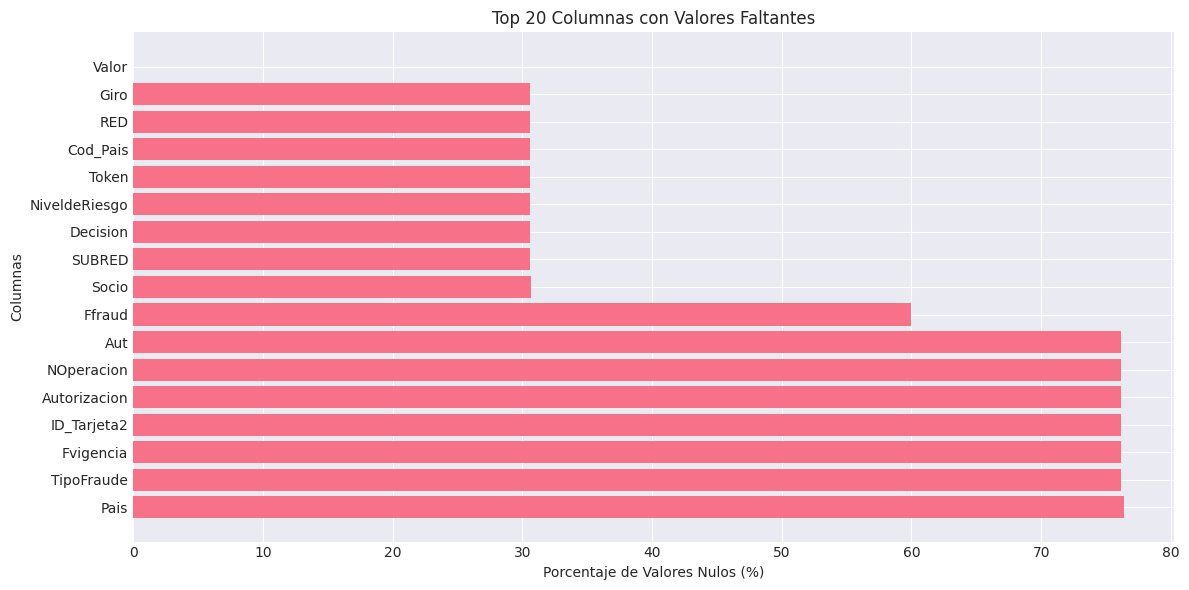

In [13]:
# Visualización de valores nulos (si existen)
if len(null_df) > 0:
    plt.figure(figsize=(12, 6))
    
    # Top 20 columnas con más nulos
    top_nulls = null_df.head(20)
    
    plt.barh(top_nulls['Columna'], top_nulls['Porcentaje (%)'])
    plt.xlabel('Porcentaje de Valores Nulos (%)')
    plt.ylabel('Columnas')
    plt.title('Top 20 Columnas con Valores Faltantes')
    plt.tight_layout()
    plt.show()

## 6. Análisis de Duplicados

In [14]:
# Verificar duplicados
duplicates = df.duplicated().sum()
duplicate_pct = (duplicates / len(df)) * 100

print(f"🔍 Análisis de Duplicados:")
print(f"   - Total de filas duplicadas: {duplicates:,}")
print(f"   - Porcentaje: {duplicate_pct:.2f}%")

if duplicates > 0:
    print(f"\n⚠️ Se encontraron {duplicates:,} filas duplicadas")
else:
    print("\n✅ No se encontraron filas duplicadas")

🔍 Análisis de Duplicados:
   - Total de filas duplicadas: 8,243
   - Porcentaje: 13.08%

⚠️ Se encontraron 8,243 filas duplicadas


## 7. Análisis de la Variable Objetivo (si existe)

Identifica automáticamente columnas que podrían ser la variable objetivo de fraude

🎯 Variable objetivo identificada: 'Ffraud'

📊 Distribución de la variable objetivo:


,Valor,Cantidad,Porcentaje (%)
0,0006-10-25,319,1.263416
1,0005-11-25,318,1.259456
2,0007-10-25,314,1.243614
3,0008-04-25,311,1.231732
4,0007-12-25,310,1.227771
...,...,...,...
115,0001-02-25,122,0.483187
116,0001-05-25,120,0.475266
117,2010-12-25,113,0.447542
118,0002-03-25,109,0.431700


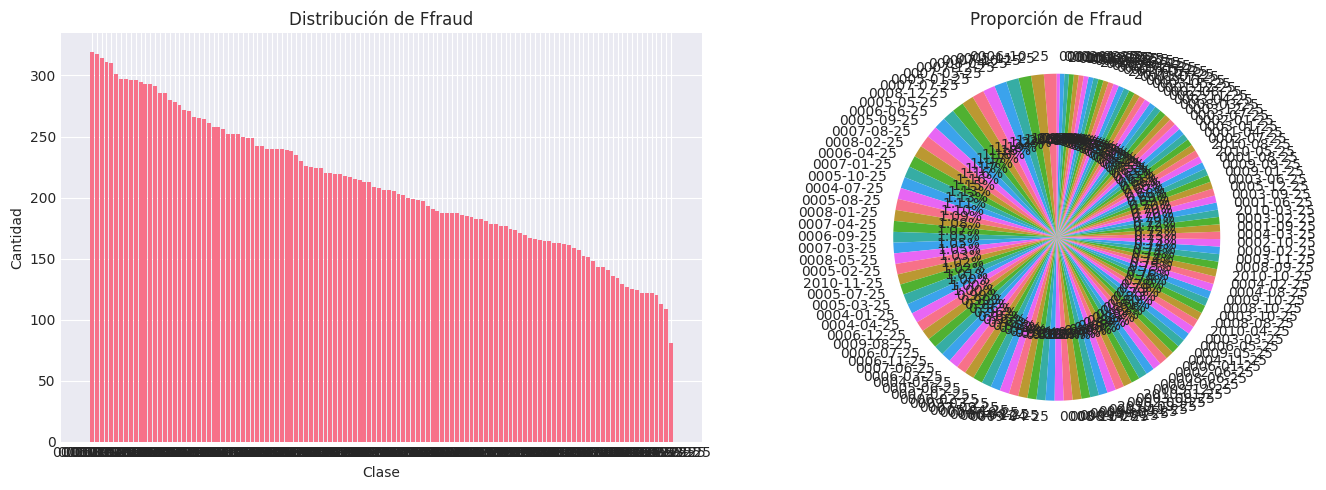

In [15]:
# Buscar columna objetivo (fraude, fraud, target, etc.)
target_keywords = ['fraude', 'fraud', 'target', 'label', 'class', 'is_fraud']
target_col = None

for col in df.columns:
    if any(keyword in col.lower() for keyword in target_keywords):
        target_col = col
        break

if target_col:
    print(f"🎯 Variable objetivo identificada: '{target_col}'\n")
    
    # Distribución de la variable objetivo
    value_counts = df[target_col].value_counts()
    value_pct = df[target_col].value_counts(normalize=True) * 100
    
    target_dist = pd.DataFrame({
        'Valor': value_counts.index,
        'Cantidad': value_counts.values,
        'Porcentaje (%)': value_pct.values
    })
    
    print("📊 Distribución de la variable objetivo:")
    display(target_dist)
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de barras
    axes[0].bar(target_dist['Valor'].astype(str), target_dist['Cantidad'])
    axes[0].set_xlabel('Clase')
    axes[0].set_ylabel('Cantidad')
    axes[0].set_title(f'Distribución de {target_col}')
    
    # Gráfico de pastel
    axes[1].pie(target_dist['Cantidad'], labels=target_dist['Valor'].astype(str), 
                autopct='%1.2f%%', startangle=90)
    axes[1].set_title(f'Proporción de {target_col}')
    
    plt.tight_layout()
    plt.show()
    
    # Calcular desbalance
    if len(value_counts) == 2:
        imbalance_ratio = value_counts.max() / value_counts.min()
        print(f"\n⚖️ Ratio de desbalance: {imbalance_ratio:.2f}:1")
        
        if imbalance_ratio > 10:
            print("⚠️ Dataset altamente desbalanceado. Considerar técnicas de balanceo.")
else:
    print("⚠️ No se identificó automáticamente una variable objetivo")
    print("Columnas disponibles:")
    print(df.columns.tolist())

## 8. Análisis de Tipos de Datos

In [16]:
# Resumen de tipos de datos
dtype_counts = df.dtypes.value_counts()

print("📊 Resumen de tipos de datos:\n")
for dtype, count in dtype_counts.items():
    print(f"   - {dtype}: {count} columnas")

# Separar por tipo
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

print(f"\n   - Numéricas: {len(numeric_cols)}")
print(f"   - Categóricas: {len(categorical_cols)}")
print(f"   - Fechas: {len(datetime_cols)}")

📊 Resumen de tipos de datos:

   - object: 22 columnas
   - float64: 4 columnas
   - category: 1 columnas

   - Numéricas: 4
   - Categóricas: 23
   - Fechas: 0


## 9. Guardar Dataset Limpio (Opcional)

Después de realizar las transformaciones de limpieza, puedes guardar el dataset procesado

In [17]:
# Ejemplo de guardado (descomentar cuando sea necesario)
'''
OUTPUT_PATH = f"s3://{BUCKET}/modelo_fraude/processed/df_fraudes_cleaned.parquet"

print(f"💾 Guardando dataset limpio en: {OUTPUT_PATH}")

df_cleaned.to_parquet(
    OUTPUT_PATH,
    storage_options={'use_ssl': True},
    index=False
)

print("✅ Dataset guardado exitosamente")
'''
print("💡 Código de guardado disponible (comentado)")

💡 Código de guardado disponible (comentado)
